In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.DataFrame(columns = ["Model", "Dataset", "Visited nodes", "Applied prunes"])

for file in os.listdir("./results"):
    file_name = file.split(".txt")[0]
    model, dataset = file_name.split("_")
    with open(f"./results/{file}", "r") as f:
        visited_nodes = int(f.readline().strip().split(": ")[1])
        f.readline()  # Skip credible sugroups
        f.readline()  # Skip selected subgroups
        if model != "QFinder":
            applied_prunes = int(f.readline().strip().split(": ")[1])
        else:
            applied_prunes = pd.NA
    df.loc[len(df)] = [model, dataset, visited_nodes, applied_prunes]

In [3]:
df.head()

,Model,Dataset,Visited nodes,Applied prunes
0,SDMapStar,Cardio,1284,0
1,BerryFinderNoPrune,Cardio,1951,801
2,BSD,StudentSuccess,61976489,15594587
3,BSD,Mushrooms,1443113,87068
4,BerryFinder,connect4,2384049,47004


In [4]:
df["Model"] = df["Model"].replace({
    "QFinder": "Q-Finder",
    "SDMapStar": "SDMap*",
    "BerryFinderNoPrune": "BerryFinder (no pruning)"
})

In [5]:
algorithm_order = order = [ "BSD", "SDMap*", "Q-Finder","BerryFinder" ,"BerryFinder (no pruning)"]

df = df.sort_values(by="Model", key=lambda x: x.map({model: i for i, model in enumerate(algorithm_order)}))

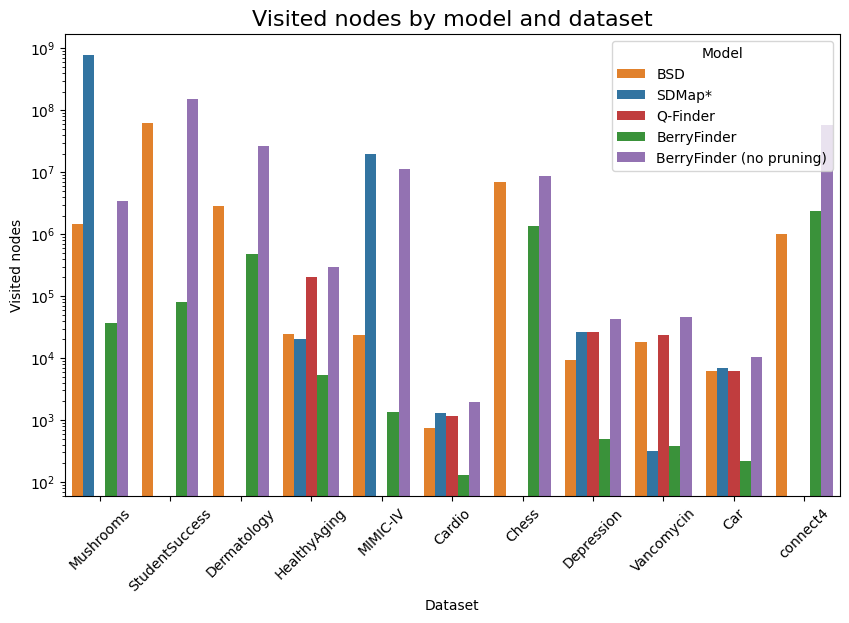

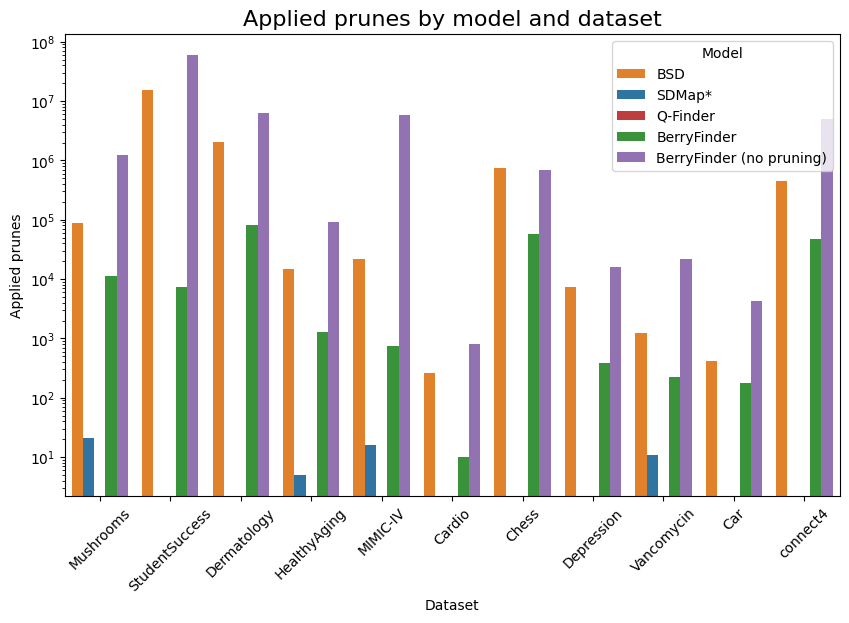

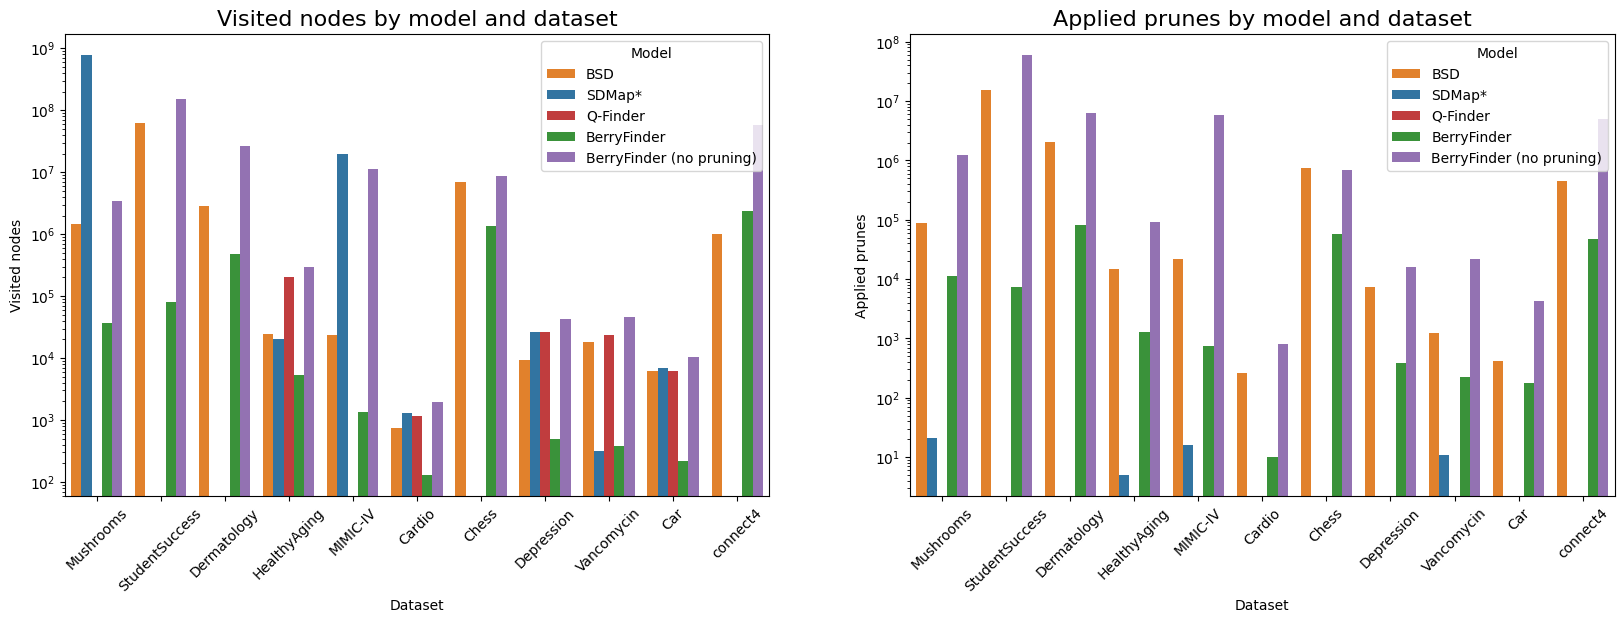

In [7]:
palette = {
    "Q-Finder": "tab:red",
    "BerryFinder": "tab:green",
    "SDMap*": "tab:blue",
    "BSD" : "tab:orange",
    "BerryFinder (no pruning)": "tab:purple"
}


fontsize = 16

fig = plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Dataset", y="Visited nodes", hue="Model", palette=palette)
plt.yscale("log")
plt.title("Visited nodes by model and dataset", fontsize=fontsize)
# Tilt x labels
plt.xticks(rotation=45)

fig = plt.figure(figsize=(10, 6))
sns.barplot(data=df[df["Model"] != "QFinder"], x="Dataset", y="Applied prunes", hue="Model", palette=palette)
plt.yscale("log")
plt.title("Applied prunes by model and dataset", fontsize=fontsize)
# Tilt x labels
plt.xticks(rotation=45)
plt.show()

# Join both plots

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
sns.barplot(data=df, x="Dataset", y="Visited nodes", hue="Model", ax=axes[0], palette=palette)
axes[0].set_yscale("log")
axes[0].set_title("Visited nodes by model and dataset", fontsize=fontsize)
# Tilt x labels
axes[0].tick_params(axis='x', rotation=45) 

sns.barplot(data=df[df["Model"] != "QFinder"], x="Dataset", y="Applied prunes", hue="Model", ax=axes[1], palette=palette)
axes[1].set_yscale("log")
axes[1].set_title("Applied prunes by model and dataset", fontsize=fontsize)
# Tilt x labels
axes[1].tick_params(axis='x', rotation=45)
plt.show()